In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Set global font size increase
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 13,
    'axes.linewidth': 1.5,
    'lines.linewidth': 2.5
})

# Create directory if it doesn't exist
PATH = "../../reports/figures/memory"
os.makedirs(PATH, exist_ok=True)

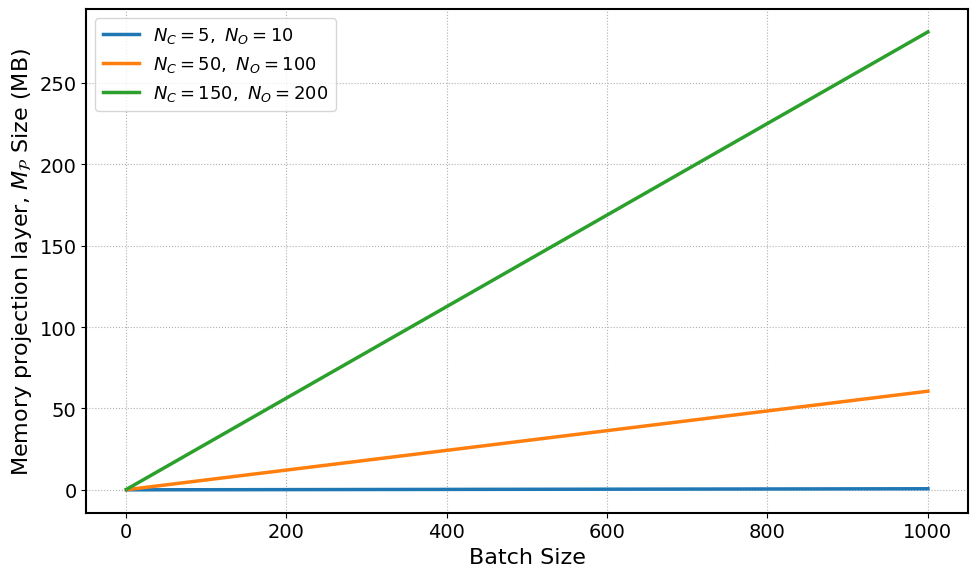

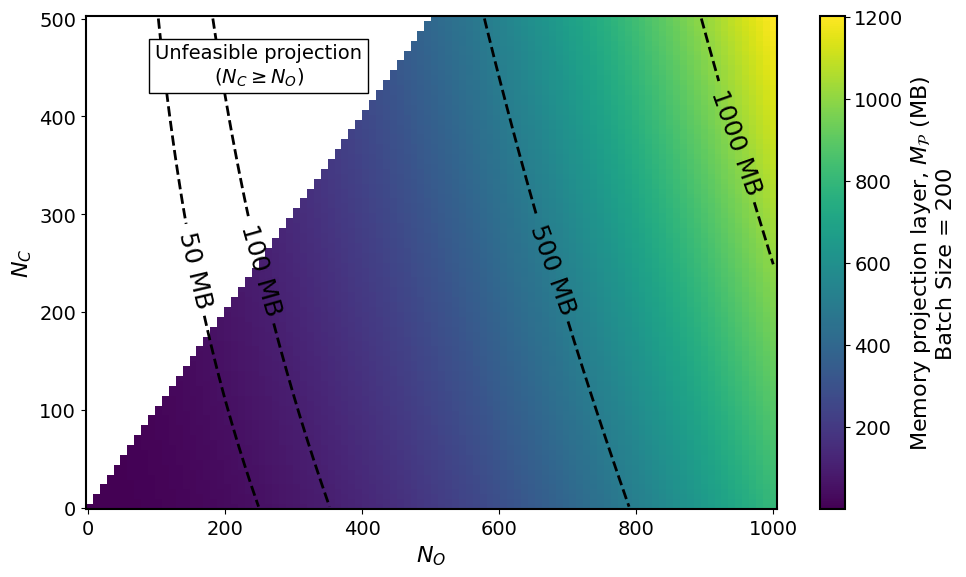

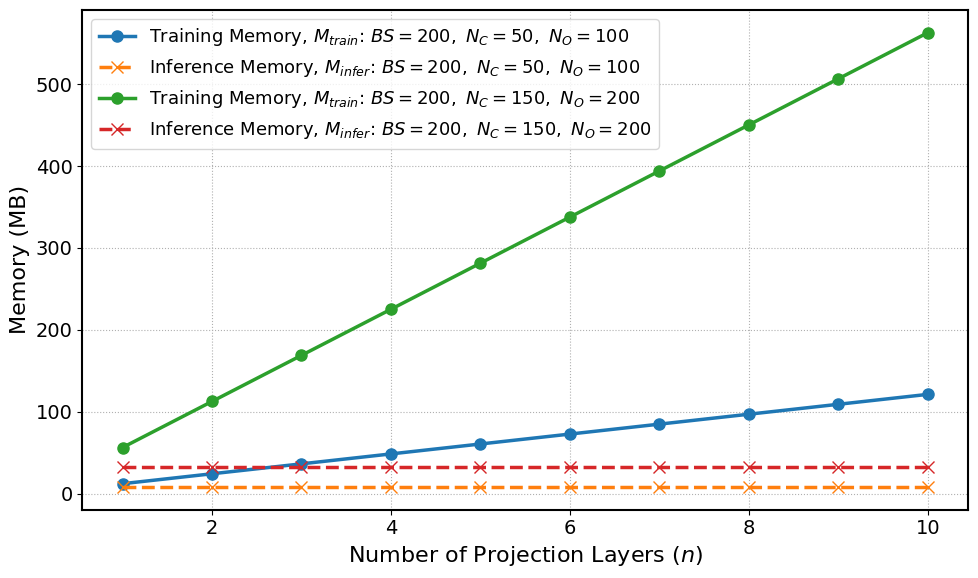

In [4]:
# Sampled parameter ranges
BS_vals = np.linspace(1, 1000, 10) # batch size
n_vals = range(1, 11) # number of projection steps

# Memory formulas (returning values in Megabytes)
def M_p(BS, NC, NO):
    return 4 * BS * (NO + 1) * (NC + NO) / 1e6  # bytes to MB

def M_train(BS, NC, NO, n):
    return 4 * n * BS * (NO + 1) * (NC + NO) / 1e6

def M_infer(BS, NO):
    return 4 * BS * (NO + 1) * NO / 1e6

# 1. M_p vs BS
plt.figure(figsize=(10, 6))
for NC, NO in [(5,10), (50,100), (150,200)]:
    plt.plot(BS_vals, [M_p(BS, NC, NO) for BS in BS_vals], label=rf'$N_C={NC},\ N_O={NO}$')
plt.xlabel(r'Batch Size')
plt.ylabel(r'Memory projection layer, $M_{\mathcal{P}}$ Size (MB)')
plt.grid(True, linestyle=':')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(PATH,"M_p_vs_BS.png"), dpi=300)
plt.show()

# 2. M_p heatmap at BS=200 with contour lines
# parameters
BS = 200
NC = np.linspace(1, 500, 100)
NO = np.linspace(2, 1000, 100)
NC_mesh, NO_mesh = np.meshgrid(NC, NO, indexing='ij')

# the quantity to plot
Z = 4 * BS * (NO_mesh + 1) * (NC_mesh + NO_mesh) / 1e6

# mask = True where N_C >= N_O
mask = NC_mesh >= NO_mesh

fig, ax = plt.subplots(figsize=(10, 6))

# 1) main heatmap, with the infeasible region masked away
pcm = ax.pcolormesh(
    NO_mesh, NC_mesh, 
    np.ma.masked_where(mask, Z), 
    shading='auto'
)

# 2) your dashed contour‐lines (will default to black)
cs = ax.contour(
    NO_mesh, NC_mesh, Z,
    levels=[50, 100, 500, 1000, 2000],
    linestyles='dashed',
    linewidths=2,
    colors='black'
)
manual_positions = []
for level_idx, segs in enumerate(cs.allsegs):
    # drop any empty segments
    nonzero = [seg for seg in segs if seg.shape[0] > 0]
    if not nonzero:
        # no valid path for this level → skip it
        continue
    # pick the longest surviving segment
    longest = max(nonzero, key=lambda seg: seg.shape[0])
    # take its midpoint vertex
    mid = longest[len(longest)//2]
    manual_positions.append((mid[0], mid[1]))

# now place one label at each of those mids
ax.clabel(
    cs,
    inline=True,
    fmt='%1.0f MB',
    fontsize=18,
    manual=manual_positions,
    inline_spacing=5
)

# 3) hatched overlay exactly over mask==True
#    we convert mask to int (1 inside, 0 outside), then contourf at [0.5,1.5]
ax.contourf(
    NO_mesh, NC_mesh, mask.astype(int),
    levels=[0.5, 1.5],
    colors='none',       # no solid color
    # hatches=['///'],     # diagonal hatch
    alpha=0,

)


# 4) annotation
ax.text(
    0.25, 0.9, "Unfeasible projection\n($N_C \geq N_O$)",
    transform=ax.transAxes,
    fontsize=14, ha='center', va='center',
    bbox=dict(facecolor='white', alpha=1)
)

# 5) colorbar + labels
cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label('Memory projection layer, $M_{\\mathcal{P}}$ (MB)\nBatch Size = 200')
cbar.ax.tick_params(labelsize=14)

ax.set_xlabel(r'$N_O$')
ax.set_ylabel(r'$N_C$')
plt.tight_layout()
plt.savefig(os.path.join(PATH,"M_p_heatmap_new.png"), dpi=300)
plt.show()


# 3. M_train vs n with M_infer
plt.figure(figsize=(10, 6))
for BS, NC, NO in [(200, 50, 100), (200, 150, 200)]:
    # Training memory
    plt.plot(
        list(n_vals),
        [M_train(BS, NC, NO, n) for n in n_vals],
        label=rf'Training Memory, $M_{{train}}$: $BS={BS},\ N_C={NC},\ N_O={NO}$',
        marker='o',
        markersize=8
    )
    infer_mem = M_infer(BS, NO)
    plt.plot(
        list(n_vals),
        [infer_mem] * len(n_vals),
        label=rf'Inference Memory, $M_{{infer}}$: $BS={BS},\ N_C={NC},\ N_O={NO}$',
        linestyle='--',
        marker='x',
        markersize=8
    )
    
plt.xlabel(r'Number of Projection Layers ($n$)')
plt.ylabel(r'Memory (MB)')
plt.legend()
plt.grid(True, linestyle=':')
plt.tight_layout()
plt.savefig(os.path.join(PATH,"M_train_vs_n.png"), dpi=300)
plt.show()
